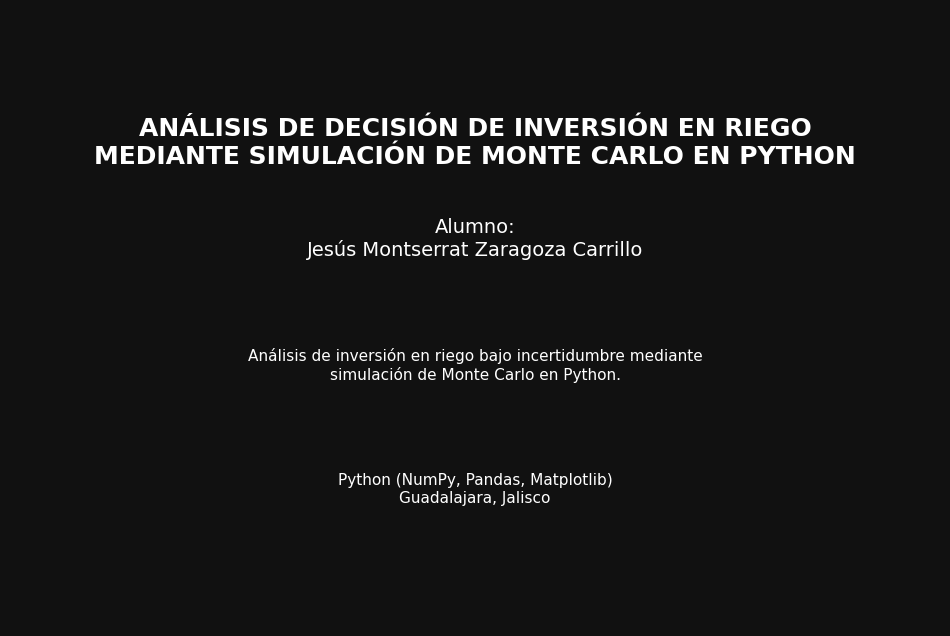

In [151]:
plt.figure(figsize=(12, 8), facecolor='#111111')
plt.axis('off')

plt.text(0.5, 0.75,
         "ANÁLISIS DE DECISIÓN DE INVERSIÓN EN RIEGO\n"
         "MEDIANTE SIMULACIÓN DE MONTE CARLO EN PYTHON",
         ha='center', fontsize=18, color='white', fontweight='bold')

plt.text(0.5, 0.60,
         "Alumno:\nJesús Montserrat Zaragoza Carrillo",
         ha='center', fontsize=14, color='white')

plt.text(0.5, 0.40,
         "Análisis de inversión en riego bajo incertidumbre mediante\n"
         "simulación de Monte Carlo en Python.",
         ha='center', fontsize=11, color='white')

plt.text(0.5, 0.20,
         "Python (NumPy, Pandas, Matplotlib)\nGuadalajara, Jalisco",
         ha='center', fontsize=11, color='white')

plt.show()

In [132]:
# Importamos numpy para generar números aleatorios y trabajar con arreglos numéricos
import numpy as np

# Importamos pandas para mostrar una tabla resumen al final
import pandas as pd

import matplotlib.pyplot as plt

#### DATOS

In [133]:
#Variables 

# Parámetros generales
hectareas = 100
horizonte = 7
n_sim = 10000
semilla = 42

# Precios históricos de la caña del caso
precios = np.array([701.49, 757.16, 755.59, 900.95, 829.39, 897.65])
precio_prom = precios.mean()



In [134]:
# Probabilidades del clima
prob_climas = {
    "normal": 0.40,
    "moderada": 0.30,
    "severa": 0.20,
    "extrema": 0.10
}

# Probabilidad de tormenta severa
prob_tormenta = 0.05

# Rendimientos SIN riego (ton/ha/año)
rend_sin_riego = {
    "normal": 60,
    "moderada": 50,
    "severa": 40,
    "extrema": 25
}

In [135]:
# Rendimientos CON riego
# En clima normal hay 3 posibles rendimientos con sus probabilidades
rend_con_riego_normal = [
    (90, 0.50),
    (120, 0.30),
    (200, 0.20)
]

# Rendimientos con riego para el resto de climas
rend_con_riego_fijo = {
    "moderada": 90,
    "severa": 70,
    "extrema": 40
}

In [136]:
# Costos anuales por hectárea
costo_sin_riego_ha = 38000
costo_con_riego_ha = 55000 + 8000   # operación + mantenimiento = 63,000

# Costos anuales totales
costo_sin_riego_total = costo_sin_riego_ha * hectareas
costo_con_riego_total = costo_con_riego_ha * hectareas

# Inversión inicial de riego
inversion_inicial_ha = 4000 * 20   # 4,000 USD * 20 MXN/USD
inversion_inicial_total = inversion_inicial_ha * hectareas

#### CALCULAR UTILIDAD

In [137]:

def utilidad_anual(rendimiento_ha, precio, hectareas, costo_total):
    """
    Calcula la utilidad anual total:
    utilidad = ingresos - costos
    ingresos = rendimiento por hectárea * precio * hectáreas
    """
    ingresos = rendimiento_ha * precio * hectareas
    utilidad = ingresos - costo_total
    return utilidad



#### ESCENARIOS PRODUCTIVOS POSIBLES Y UTILIDAD ANUAL

In [138]:
# =========================================================
# 3) ESCENARIOS PRODUCTIVOS POSIBLES Y UTILIDAD ANUAL
# =========================================================
escenarios = []

# ---- Escenarios SIN riego ----
for clima, p_clima in prob_climas.items():
    # Caso sin tormenta
    p_escenario = p_clima * (1 - prob_tormenta)
    rendimiento = rend_sin_riego[clima]
    utilidad = utilidad_anual(
        rendimiento_ha=rendimiento,
        precio=precio_prom,
        hectareas=hectareas,
        costo_total=costo_sin_riego_total
    )
    escenarios.append({
        "Alternativa": "Sin riego",
        "Clima": clima,
        "Tormenta": "No",
        "Rendimiento_ha": rendimiento,
        "Probabilidad": p_escenario,
        "Utilidad_anual": utilidad
    })

    # Caso con tormenta
    p_escenario = p_clima * prob_tormenta
    rendimiento = 0
    utilidad = utilidad_anual(
        rendimiento_ha=rendimiento,
        precio=precio_prom,
        hectareas=hectareas,
        costo_total=costo_sin_riego_total
    )
    escenarios.append({
        "Alternativa": "Sin riego",
        "Clima": clima,
        "Tormenta": "Sí",
        "Rendimiento_ha": rendimiento,
        "Probabilidad": p_escenario,
        "Utilidad_anual": utilidad
    })

# ---- Escenarios CON riego ----
for clima, p_clima in prob_climas.items():
    if clima == "normal":
        # Clima normal + sin tormenta + subescenarios de rendimiento
        for rendimiento, p_rend in rend_con_riego_normal:
            p_escenario = p_clima * (1 - prob_tormenta) * p_rend
            utilidad = utilidad_anual(
                rendimiento_ha=rendimiento,
                precio=precio_prom,
                hectareas=hectareas,
                costo_total=costo_con_riego_total
            )
            escenarios.append({
                "Alternativa": "Con riego",
                "Clima": clima,
                "Tormenta": "No",
                "Rendimiento_ha": rendimiento,
                "Probabilidad": p_escenario,
                "Utilidad_anual": utilidad
            })

        # Clima normal + tormenta
        p_escenario = p_clima * prob_tormenta
        rendimiento = 0
        utilidad = utilidad_anual(
            rendimiento_ha=rendimiento,
            precio=precio_prom,
            hectareas=hectareas,
            costo_total=costo_con_riego_total
        )
        escenarios.append({
            "Alternativa": "Con riego",
            "Clima": clima,
            "Tormenta": "Sí",
            "Rendimiento_ha": rendimiento,
            "Probabilidad": p_escenario,
            "Utilidad_anual": utilidad
        })

    else:
        # Otros climas con riego
        # Sin tormenta
        p_escenario = p_clima * (1 - prob_tormenta)
        rendimiento = rend_con_riego_fijo[clima]
        utilidad = utilidad_anual(
            rendimiento_ha=rendimiento,
            precio=precio_prom,
            hectareas=hectareas,
            costo_total=costo_con_riego_total
        )
        escenarios.append({
            "Alternativa": "Con riego",
            "Clima": clima,
            "Tormenta": "No",
            "Rendimiento_ha": rendimiento,
            "Probabilidad": p_escenario,
            "Utilidad_anual": utilidad
        })

        # Con tormenta
        p_escenario = p_clima * prob_tormenta
        rendimiento = 0
        utilidad = utilidad_anual(
            rendimiento_ha=rendimiento,
            precio=precio_prom,
            hectareas=hectareas,
            costo_total=costo_con_riego_total
        )
        escenarios.append({
            "Alternativa": "Con riego",
            "Clima": clima,
            "Tormenta": "Sí",
            "Rendimiento_ha": rendimiento,
            "Probabilidad": p_escenario,
            "Utilidad_anual": utilidad
        })

# Convertimos a DataFrame
df_escenarios = pd.DataFrame(escenarios)

# Redondeo para presentación
df_escenarios["Probabilidad"] = df_escenarios["Probabilidad"].round(4)
df_escenarios["Utilidad_anual"] = df_escenarios["Utilidad_anual"].round(2)

print("=" * 80)
print("1) ESCENARIOS PRODUCTIVOS POSIBLES Y UTILIDAD ANUAL")
print("=" * 80)
print(df_escenarios.to_string(index=False))

1) ESCENARIOS PRODUCTIVOS POSIBLES Y UTILIDAD ANUAL
Alternativa    Clima Tormenta  Rendimiento_ha  Probabilidad  Utilidad_anual
  Sin riego   normal       No              60         0.380      1042230.00
  Sin riego   normal       Sí               0         0.020     -3800000.00
  Sin riego moderada       No              50         0.285       235191.67
  Sin riego moderada       Sí               0         0.015     -3800000.00
  Sin riego   severa       No              40         0.190      -571846.67
  Sin riego   severa       Sí               0         0.010     -3800000.00
  Sin riego  extrema       No              25         0.095     -1782404.17
  Sin riego  extrema       Sí               0         0.005     -3800000.00
  Con riego   normal       No              90         0.190       963345.00
  Con riego   normal       No             120         0.114      3384460.00
  Con riego   normal       No             200         0.076      9840766.67
  Con riego   normal       Sí       

#### UTILIDAD ANUAL DE CADA ALTERNATIVA

In [139]:

utilidad_esperada_anual = (
    df_escenarios
    .groupby("Alternativa")
    .apply(lambda x: (x["Probabilidad"] * x["Utilidad_anual"]).sum())
    .reset_index(name="Utilidad_esperada_anual")
)

utilidad_esperada_anual["Utilidad_esperada_anual"] = (
    utilidad_esperada_anual["Utilidad_esperada_anual"].round(2)
)

print("\n" + "=" * 80)
print("2) UTILIDAD ESPERADA ANUAL DE CADA ALTERNATIVA")
print("=" * 80)
print(utilidad_esperada_anual.to_string(index=False))


2) UTILIDAD ESPERADA ANUAL DE CADA ALTERNATIVA
Alternativa  Utilidad_esperada_anual
  Con riego                860851.13
  Sin riego                 -4902.24


C:\Users\monts\AppData\Local\Temp\ipykernel_31292\4127644505.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x["Probabilidad"] * x["Utilidad_anual"]).sum())


#### UTILIDAD ACUMULADA ESPERADA EN 7 AÑOS

In [140]:

# Sin riego: utilidad esperada anual * 7
# Con riego: utilidad esperada anual * 7 - inversión inicial
fila_sin = utilidad_esperada_anual.loc[
    utilidad_esperada_anual["Alternativa"] == "Sin riego",
    "Utilidad_esperada_anual"
].values[0]

fila_con = utilidad_esperada_anual.loc[
    utilidad_esperada_anual["Alternativa"] == "Con riego",
    "Utilidad_esperada_anual"
].values[0]

utilidad_7_sin = fila_sin * horizonte
utilidad_7_con = (fila_con * horizonte) - inversion_inicial_total

df_7_anios = pd.DataFrame({
    "Alternativa": ["Sin riego", "Con riego"],
    "Utilidad_esperada_7_anios": [utilidad_7_sin, utilidad_7_con]
})

df_7_anios["Utilidad_esperada_7_anios"] = df_7_anios["Utilidad_esperada_7_anios"].round(2)

print("\n" + "=" * 80)
print("3) UTILIDAD ACUMULADA ESPERADA EN 7 AÑOS")
print("=" * 80)
print(df_7_anios.to_string(index=False))



3) UTILIDAD ACUMULADA ESPERADA EN 7 AÑOS
Alternativa  Utilidad_esperada_7_anios
  Sin riego                  -34315.68
  Con riego                -1974042.09


#### SIMULACIÓN MONTE CARLO DE 10,000 ESCENARIOS

In [141]:
# =========================================================
# 6) SIMULACIÓN MONTE CARLO DE 10,000 ESCENARIOS
# =========================================================
rng = np.random.default_rng(semilla)

climas_lista = list(prob_climas.keys())
prob_lista = list(prob_climas.values())

def simular_un_anio_sin_riego(rng):
    clima = rng.choice(climas_lista, p=prob_lista)
    tormenta = rng.random() < prob_tormenta

    if tormenta:
        rendimiento = 0
    else:
        rendimiento = rend_sin_riego[clima]

    utilidad = utilidad_anual(
        rendimiento_ha=rendimiento,
        precio=precio_prom,
        hectareas=hectareas,
        costo_total=costo_sin_riego_total
    )
    return utilidad

def simular_un_anio_con_riego(rng):
    clima = rng.choice(climas_lista, p=prob_lista)
    tormenta = rng.random() < prob_tormenta

    if tormenta:
        rendimiento = 0
    else:
        if clima == "normal":
            rendimientos = [x[0] for x in rend_con_riego_normal]
            probabilidades = [x[1] for x in rend_con_riego_normal]
            rendimiento = rng.choice(rendimientos, p=probabilidades)
        else:
            rendimiento = rend_con_riego_fijo[clima]

    utilidad = utilidad_anual(
        rendimiento_ha=rendimiento,
        precio=precio_prom,
        hectareas=hectareas,
        costo_total=costo_con_riego_total
    )
    return utilidad

# Simulación de horizonte completo de 7 años
sim_sin = []
sim_con = []

for _ in range(n_sim):
    total_sin = 0
    total_con = -inversion_inicial_total  # riego arranca restando la inversión inicial

    for _ in range(horizonte):
        total_sin += simular_un_anio_sin_riego(rng)
        total_con += simular_un_anio_con_riego(rng)

    sim_sin.append(total_sin)
    sim_con.append(total_con)

sim_sin = np.array(sim_sin)
sim_con = np.array(sim_con)

# Utilidad promedio de cada opción
promedio_sin = sim_sin.mean()
promedio_con = sim_con.mean()

# Probabilidad de que riego sea más rentable que no invertir
prob_riego_mejor = np.mean(sim_con > sim_sin)

df_sim = pd.DataFrame({
    "Alternativa": ["Sin riego", "Con riego"],
    "Utilidad_promedio_simulada_7_anios": [promedio_sin, promedio_con]
})

df_sim["Utilidad_promedio_simulada_7_anios"] = df_sim["Utilidad_promedio_simulada_7_anios"].round(2)

print("\n" + "=" * 80)
print("4) RESULTADOS DE LA SIMULACIÓN MONTE CARLO (10,000 ESCENARIOS)")
print("=" * 80)
print(df_sim.to_string(index=False))
print("\nProbabilidad de que invertir en riego resulte más rentable:", round(prob_riego_mejor, 4))



4) RESULTADOS DE LA SIMULACIÓN MONTE CARLO (10,000 ESCENARIOS)
Alternativa  Utilidad_promedio_simulada_7_anios
  Sin riego                           -32298.07
  Con riego                         -1875179.88

Probabilidad de que invertir en riego resulte más rentable: 0.3964


#### COMPARACIÓN DE CRITERIOS DE DECISIÓN

In [142]:


# Criterio 1: mayor utilidad esperada
if utilidad_7_con > utilidad_7_sin:
    recomendacion_utilidad_esperada = "Con riego"
else:
    recomendacion_utilidad_esperada = "Sin riego"

# Criterio 2: mayoría de escenarios favorables
# Si la probabilidad de que riego gane > 0.50, entonces gana riego
if prob_riego_mejor > 0.50:
    recomendacion_mayoria_escenarios = "Con riego"
else:
    recomendacion_mayoria_escenarios = "Sin riego"

comparacion = pd.DataFrame({
    "Criterio": [
        "Mayor utilidad esperada en 7 años",
        "Mayoría de escenarios favorables"
    ],
    "Recomendacion": [
        recomendacion_utilidad_esperada,
        recomendacion_mayoria_escenarios
    ]
})

print("\n" + "=" * 80)
print("5) COMPARACIÓN DE RECOMENDACIONES")
print("=" * 80)
print(comparacion.to_string(index=False))


5) COMPARACIÓN DE RECOMENDACIONES
                         Criterio Recomendacion
Mayor utilidad esperada en 7 años     Sin riego
 Mayoría de escenarios favorables     Sin riego


#### CONCLUSIÓN AUTOMÁTICA

In [143]:

print("\n" + "=" * 80)
print("6) CONCLUSIÓN")
print("=" * 80)

print(f"Precio promedio usado: ${precio_prom:.2f} por tonelada.")
print(f"Utilidad esperada anual sin riego: ${fila_sin:,.2f}")
print(f"Utilidad esperada anual con riego: ${fila_con:,.2f}")
print(f"Utilidad esperada acumulada en 7 años sin riego: ${utilidad_7_sin:,.2f}")
print(f"Utilidad esperada acumulada en 7 años con riego: ${utilidad_7_con:,.2f}")
print(f"Probabilidad simulada de que riego supere a no invertir: {prob_riego_mejor:.2%}")

if recomendacion_utilidad_esperada == recomendacion_mayoria_escenarios:
    print(f"\nAmbos criterios coinciden en recomendar: {recomendacion_utilidad_esperada}.")
else:
    print("\nLos criterios NO coinciden.")
    print(f"- Por utilidad esperada se recomienda: {recomendacion_utilidad_esperada}")
    print(f"- Por mayoría de escenarios favorables se recomienda: {recomendacion_mayoria_escenarios}")

print("\nInterpretación sugerida:")
if recomendacion_utilidad_esperada == "Sin riego" and recomendacion_mayoria_escenarios == "Sin riego":
    print("No conviene invertir en riego, porque la inversión inicial no se recupera en el horizonte de 7 años y, además, en la mayoría de los escenarios simulados el temporal resulta más rentable.")
elif recomendacion_utilidad_esperada == "Con riego" and recomendacion_mayoria_escenarios == "Con riego":
    print("Conviene invertir en riego, porque tanto la utilidad esperada como la mayoría de escenarios simulados favorecen esta opción.")
else:
    print("La decisión depende del criterio: una opción puede ofrecer mayor valor esperado, pero perder en frecuencia frente a la otra. En ese caso, debe considerarse también la tolerancia al riesgo del productor.")


6) CONCLUSIÓN
Precio promedio usado: $807.04 por tonelada.
Utilidad esperada anual sin riego: $-4,902.24
Utilidad esperada anual con riego: $860,851.13
Utilidad esperada acumulada en 7 años sin riego: $-34,315.68
Utilidad esperada acumulada en 7 años con riego: $-1,974,042.09
Probabilidad simulada de que riego supere a no invertir: 39.64%

Ambos criterios coinciden en recomendar: Sin riego.

Interpretación sugerida:
No conviene invertir en riego, porque la inversión inicial no se recupera en el horizonte de 7 años y, además, en la mayoría de los escenarios simulados el temporal resulta más rentable.


#### Resultados Graficados

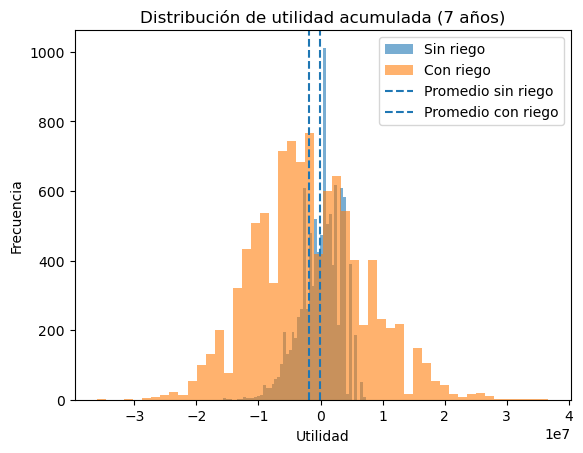

C:\Users\monts\AppData\Local\Temp\ipykernel_31292\351415310.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([sim_sin, sim_con],


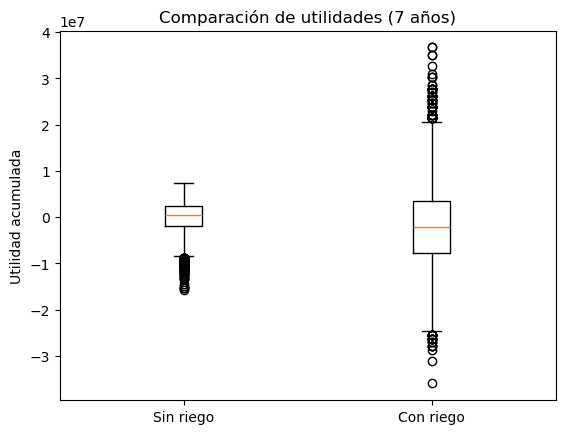

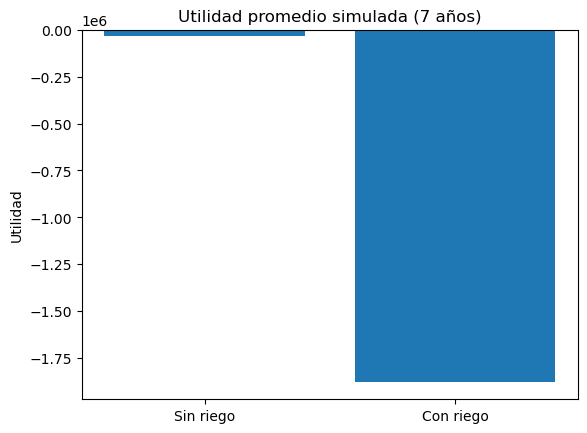

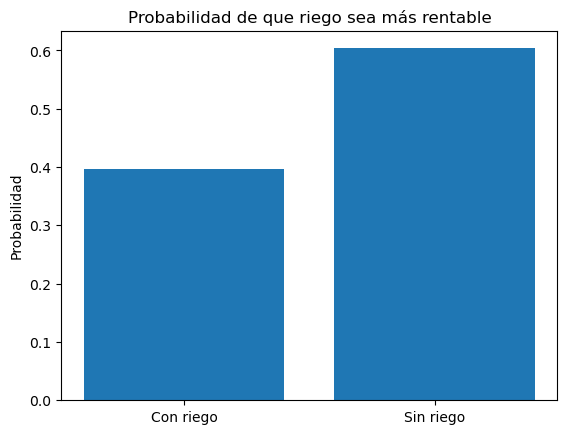

In [144]:


# =========================================================
# 1) HISTOGRAMA DE UTILIDADES (COMPARACIÓN)
# =========================================================
plt.figure()

plt.hist(sim_sin, bins=50, alpha=0.6, label="Sin riego")
plt.hist(sim_con, bins=50, alpha=0.6, label="Con riego")

plt.axvline(promedio_sin, linestyle='--', label="Promedio sin riego")
plt.axvline(promedio_con, linestyle='--', label="Promedio con riego")

plt.title("Distribución de utilidad acumulada (7 años)")
plt.xlabel("Utilidad")
plt.ylabel("Frecuencia")
plt.legend()

plt.show()


# =========================================================
# 2) BOXPLOT (MUY CLARO PARA DECISIÓN)
# =========================================================
plt.figure()

plt.boxplot([sim_sin, sim_con],
            labels=["Sin riego", "Con riego"])

plt.title("Comparación de utilidades (7 años)")
plt.ylabel("Utilidad acumulada")

plt.show()


# =========================================================
# 3) GRÁFICA DE PROMEDIOS
# =========================================================
plt.figure()

plt.bar(["Sin riego", "Con riego"],
        [promedio_sin, promedio_con])

plt.title("Utilidad promedio simulada (7 años)")
plt.ylabel("Utilidad")

plt.show()


# =========================================================
# 4) PROBABILIDAD DE QUE RIEGO SEA MEJOR
# =========================================================
plt.figure()

plt.bar(["Con riego", "Sin riego"],
        [prob_riego_mejor, 1 - prob_riego_mejor])

plt.title("Probabilidad de que riego sea más rentable")
plt.ylabel("Probabilidad")

plt.show()